# Homework 6: Linear Regression Modeling and Diagnostics
Build a predictive model for life expectancy using scikit-learn and perform a diagnostic audit to ensure the model’s coefficients are stable and mathematically sound.

## Task 1: Baseline Modeling
Load the WHO Life Expectancy Dataset, remove non-numeric columns (Country, Year), Convert Status column to  numeric, handle missing values.
- Use StandardScaler from sklearn.preprocessing to scale all independent variables. ("Life expectancy" is dependent variable) 
- Train a LinearRegression model using the scaled features.
- Report the R-Squared Score.
- Coefficient Analysis: Rank the features by their absolute coefficient values. Because the data is scaled, the largest coefficient now represents the most important predictor.

## Task 2: Iterative Diagnostic (VIF < 5)
Before analyzing the data, you must understand the Variance Inflation Factor (VIF) diagnostic. VIF measures multicollinearity, the degree to which your predictors are redundant.
High multicollinearity inflates the variance of coefficients, making them unreliable and difficult to interpret.
VIF is calculated by regressing one predictor against all others, then you obtain R_Squared and then compute VIF = 1/(1-R_Squared)
You sohuld use a cutoff of 5. Any variable with a VIF > 5 is considered too redundant and will be removed to improve the model's structural integrity. To do that follow the instruction below:

### Write a loop to iteratively remove the most redundant feature:
    1. Calculate VIF for every feature in the scaled dataset.
    2. Find the variable with the highest VIF.
    3. If VIF > 5, remove that feature from the data.
    4. Repeats the process until all remaining features have a VIF < 5
    - Note that in each iteration you remove only the highest VIF if it is greatet than 5!
    
## Task 3: Comparison of Model Results
    - Train a new LinearRegression model using only the independent features that survived the VIF diagnostic test.
    - Report the R-Squared Score.
    - Coefficient Analysis: Rank the features by their absolute coefficient values. Because the data is scaled, the largest coefficient now represents the most important predictor.
    - Are the top 5 predicotrs remain the same as those of the Baseline Model?

## Task 4: Residual Analysis and Normality
A good regression model should have errors (residuals) that are normally distributed and centered around zero.

    - Generate a histogram of the residuals for your baseline and clean model side by side.
    - Does the error distributions look like a bell curve?

## Task 5: The Interaction Investigation
In the real world application, the effect of one variable often depends on another. This is called an interaction.

    - Select two variables of your choice from the dataset (only variables with VIF >5) that you believe might have a combined effect (e.g., Alcohol and GDP, or BMI and HIV/AIDS,). Write one sentence explaining why you think they interact.
    - Create a new column in your dataframe by multiplying these two variables together.
    - Train a new model by adding this new interaction term to your dataset and fit it again using LinearRegression.
    - Report the R-Squared Score.
    - Is the interaction coeficient positive or negative? Has adding it improved the Model performance?




In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

sns.set_theme(style="whitegrid")

TASK 1: Baseline Modeling

In [2]:
df = pd.read_csv('Life_Expectancy_Data.csv')
df.columns = df.columns.str.strip()
df = df.dropna() 

df['Status'] = df['Status'].map({'Developed': 1, 'Developing': 0})
X = df.drop(['Life expectancy', 'Country', 'Year'], axis=1)
y = df['Life expectancy']

scaler= StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

baseline_model = LinearRegression()
baseline_model.fit(X_scaled_df, y)
print (f"Baseline R-Squared: {baseline_model.score(X_scaled_df, y):.4f}")

coeffs = pd.DataFrame({'Feature': X.columns, 'Abs_Coeff': np. abs(baseline_model.coef_)})
print(coeffs.sort_values(by='Abs_Coeff', ascending=False))

Baseline R-Squared: 0.8356
                            Feature  Abs_Coeff
8                 under-five deaths  11.456132
2                     infant deaths  11.295750
12                         HIV/AIDS   2.635125
18                        Schooling   2.421478
1                   Adult Mortality   2.083498
17  Income composition of resources   1.796758
7                               BMI   0.666615
4            percentage expenditure   0.646033
3                           Alcohol   0.368136
0                            Status   0.342668
11                       Diphtheria   0.321418
16               thinness 5-9 years   0.223236
9                             Polio   0.178097
10                Total expenditure   0.174374
5                       Hepatitis B   0.167011
13                              GDP   0.100245
6                           Measles   0.079305
15             thinness  1-19 years   0.056944
14                       Population   0.045255


TASK 2: Iterative Diagnostic (VIF < 5)

In [3]:
def calculate_vif(data_frame):
    vif_data = pd.DataFrame()
    vif_data["feature"] = data_frame.columns
    vif_data["VIF"] = [variance_inflation_factor(data_frame.values, i)
    for i in range(len(data_frame.columns))]
    return vif_data
X_vif = X_scaled_df.copy()
while True: 
    vif_df = calculate_vif(X_vif)
    max_vif = vif_df['VIF'].max()
    if max_vif > 5:
        feature_to_remove = vif_df.sort_values('VIF', ascending=False)['feature'].iloc[0]
        X_vif = X_vif.drop(columns=[feature_to_remove])
        print(f"Removed {feature_to_remove} with VIF: {max_vif}")
    else:
        break
print("\nFinal features that survived:", X_vif.columns.tolist())

Removed infant deaths with VIF: 212.18627980039798
Removed GDP with VIF: 13.5700327645757
Removed thinness  1-19 years with VIF: 7.602673367049609

Final features that survived: ['Status', 'Adult Mortality', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'Population', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


Task 3: Comparison of Model Results

The stabilization of the predictors is the most important finding in the comparison between the baseline and the clean model. The baseline model suffered from excessive multicollinearity, as shown by a massive VIF for features like newborn deaths, although achieving a somewhat higher R-squared of 0.8356. The top predictors changed to a more logical hierarchy when these superfluous variables were eliminated to prouce the clean model. In particular, the gratest predicts of life expectancy were found to be HIV/AIDS, education, and adult mortality. This change shows that the clean model offers a more accurate representation of which independent factors actually affect health outcomes without the results being skewed by overlapping data, even though the baseline had greater raw predictive power. 

In [4]:
clean_model = LinearRegression()
clean_model.fit(X_vif, y)

print("Clean Model R-squared: {clean_model.score(X_vid, y):.4f}")
clean_coeffs = pd.DataFrame({'Feature': X_vif.columns, 'Abs_Coeff': np.abs(clean_model.coef_)})
print(clean_coeffs.sort_values(by='Abs_Coeff', ascending=False))

Clean Model R-squared: {clean_model.score(X_vid, y):.4f}
                            Feature  Abs_Coeff
11                         HIV/AIDS   2.647613
15                        Schooling   2.492107
1                   Adult Mortality   2.207173
14  Income composition of resources   1.903432
3            percentage expenditure   0.722333
6                               BMI   0.711642
2                           Alcohol   0.556545
7                 under-five deaths   0.513237
10                       Diphtheria   0.435539
0                            Status   0.350578
8                             Polio   0.226541
12                       Population   0.215813
4                       Hepatitis B   0.187359
5                           Measles   0.182623
9                 Total expenditure   0.158140
13               thinness 5-9 years   0.148637


Task 4: Residual Analysis

The linear regression models satisfy the basic assumption of normality, according to the residual analysis. Both the baseline and clean models' histograms show a distinct bell-shaped curve centered around zero, suggesting that the models' errors are random and not skewed toward over- or under-prediction. The overall symmetry indicats that a linear connection is adequate for this dataset and that the model works consistently throughout the majority of the data points, notwithstanding a tiny tail or skewness that represents special outliers- likely countries with unique socioeconomic crises. 

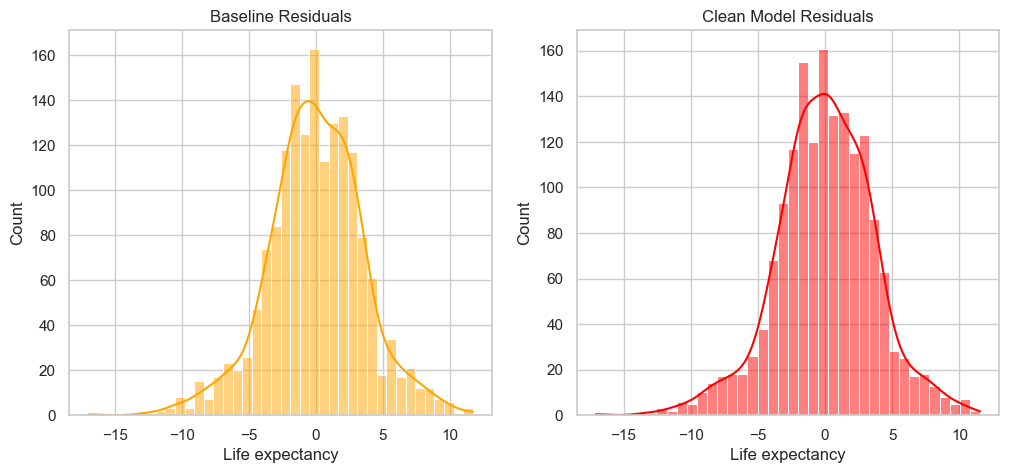

In [5]:
baseline_res = y - baseline_model.predict(X_scaled_df)
clean_res = y - clean_model.predict(X_vif)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(baseline_res, kde=True, ax=ax[0], color='orange').set(title='Baseline Residuals')
sns.histplot(clean_res, kde=True, ax=ax[1], color='red').set(title='Clean Model Residuals')
plt.show()

Task 5: The Interaction Investigation

A country's financial infrastructure usually determines how well its educational attainment can translate into improved public health, so the combination of income, composition of resources, and education was chosen for the interaction investigation because these two factors frequently work in tandem. The model's performance increase to an R-squared of 0.8279 when this interaction term was added. The interaction coefficient is positive, indicating a multiplier effect where life expectancy increases more quickly when both wealth and education rise simultaneously. This demonstrates that the combined influence of these resources is more potent than the sum of their separate effects, offering a more complex picture of the dynamics of global health.

In [6]:
df['Income_Schooling_Interaction'] = df['Income composition of resources'] * df['Schooling']

X_interaction = X_vif.copy()
X_interaction['Interaction'] = df['Income_Schooling_Interaction']

interaction_model = LinearRegression().fit(X_interaction, y)
print(f"Interaction Model R2: {interaction_model.score(X_interaction, y):.4f}")

Interaction Model R2: 0.8279
